#EDA del Dataset del Inventario

## Data Understanding & Exploratory Data Analysis (EDA)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [ ]:
# Cargar Datos
df = pd.read_csv('Grocery_Inventory_and_Sales_Dataset.csv')

In [ ]:
print('Dimension del dataframe')
print(df.shape)

Dimension del dataframe
(990, 16)


In [ ]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [ ]:
# Revisión de estructura y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product_ID               990 non-null    object
 1   Product_Name             990 non-null    object
 2   Catagory                 989 non-null    object
 3   Supplier_ID              990 non-null    object
 4   Supplier_Name            990 non-null    object
 5   Stock_Quantity           990 non-null    int64 
 6   Reorder_Level            990 non-null    int64 
 7   Reorder_Quantity         990 non-null    int64 
 8   Unit_Price               990 non-null    object
 9   Date_Received            990 non-null    object
 10  Last_Order_Date          990 non-null    object
 11  Expiration_Date          990 non-null    object
 12  Warehouse_Location       990 non-null    object
 13  Sales_Volume             990 non-null    int64 
 14  Inventory_Turnover_Rate  990 non-null    i

In [ ]:
# Identificar valores nulos
print("Valores nulos en el dataset:")
print(df.isnull().sum())

# Identificar cantidad de duplicados
print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")

Valores nulos en el dataset:
Product_ID                 0
Product_Name               0
Catagory                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

Cantidad de filas duplicadas: 0


In [ ]:
# Resumen estadistico
df.describe()

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990.000000
mean,55.609091,51.215152,51.913131,58.925253,50.150505
std,26.300775,29.095241,29.521059,23.002318,28.798954
min,10.000000,1.000000,1.000000,20.000000,1.000000
25%,33.000000,25.250000,25.000000,39.000000,25.000000
50%,56.000000,53.000000,54.000000,58.000000,50.000000
75%,79.000000,77.000000,77.000000,78.000000,74.750000
max,100.000000,100.000000,100.000000,100.000000,100.000000


### Gráficos

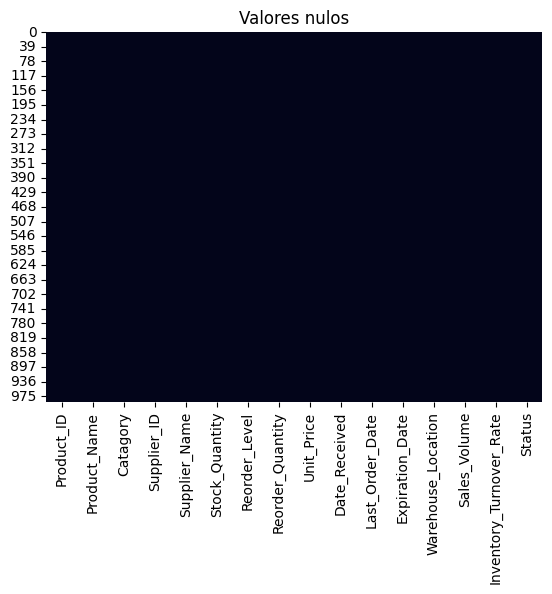

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title(f'Valores nulos')
plt.show()

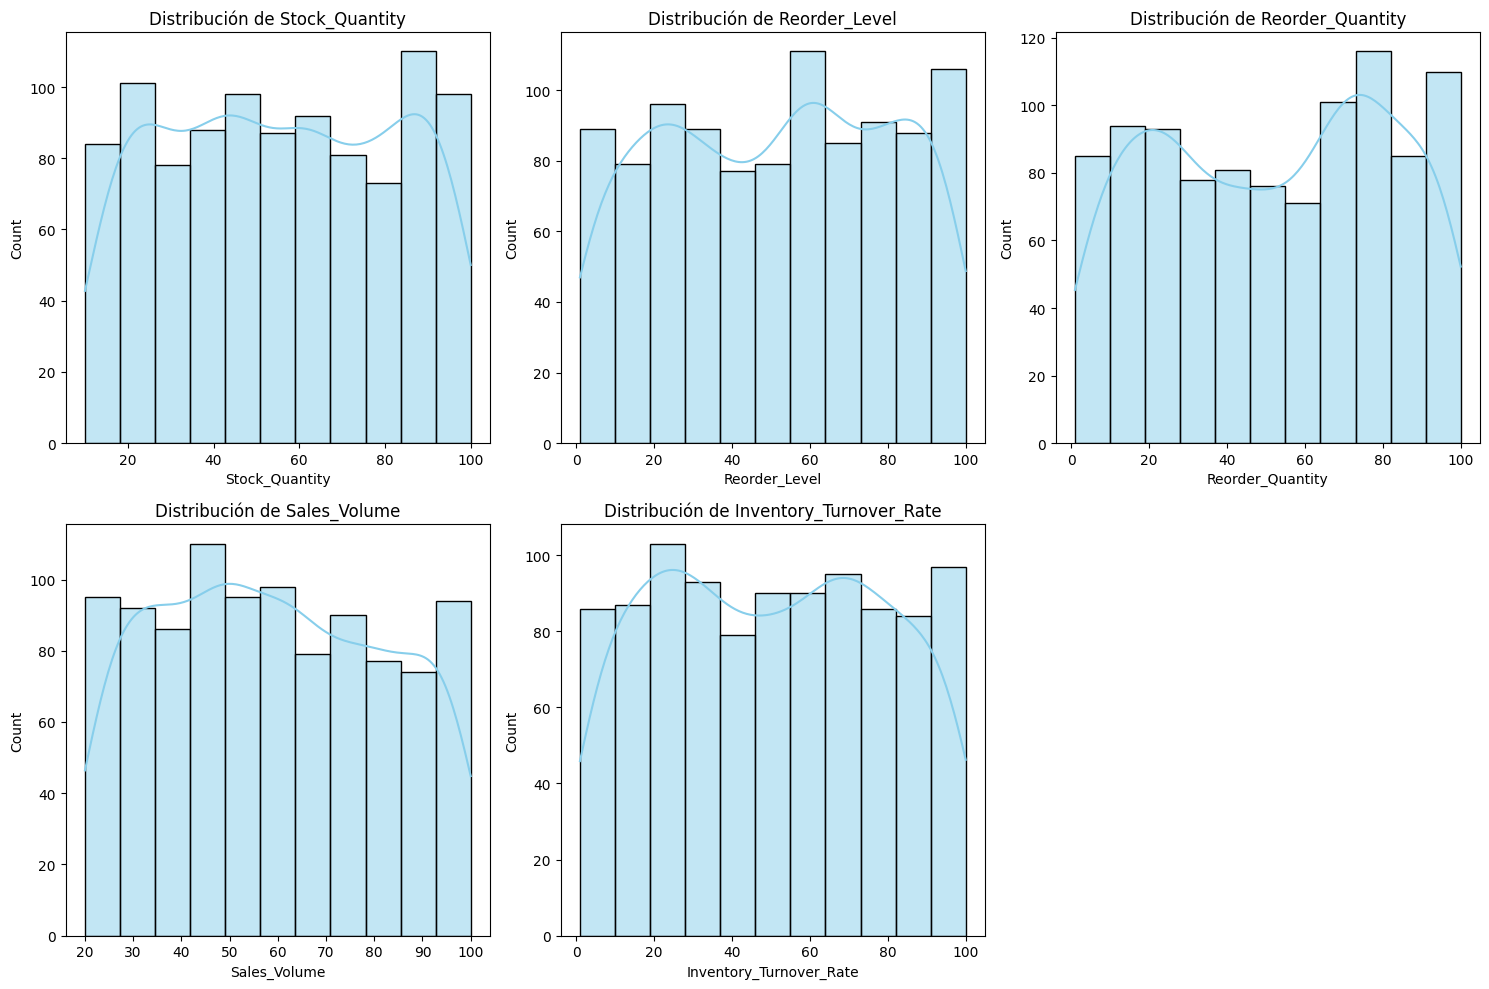

In [ ]:
# Distribución de las variables númericas
num_cols = ['Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
plt.tight_layout()

/tmp/ipykernel_19594/1617139247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Catagory', order=df['Catagory'].value_counts().index, palette='viridis')


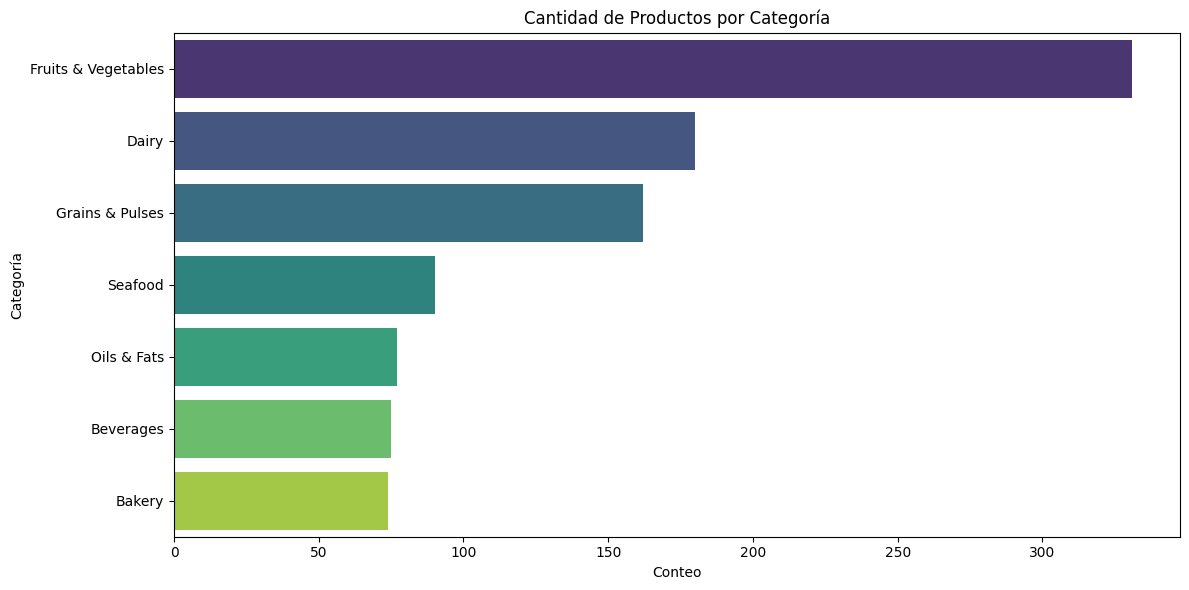

In [ ]:
# Cantidad de Productos por Categoría
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Catagory', order=df['Catagory'].value_counts().index, palette='viridis')
plt.title('Cantidad de Productos por Categoría')
plt.xlabel('Conteo')
plt.ylabel('Categoría')
plt.tight_layout()

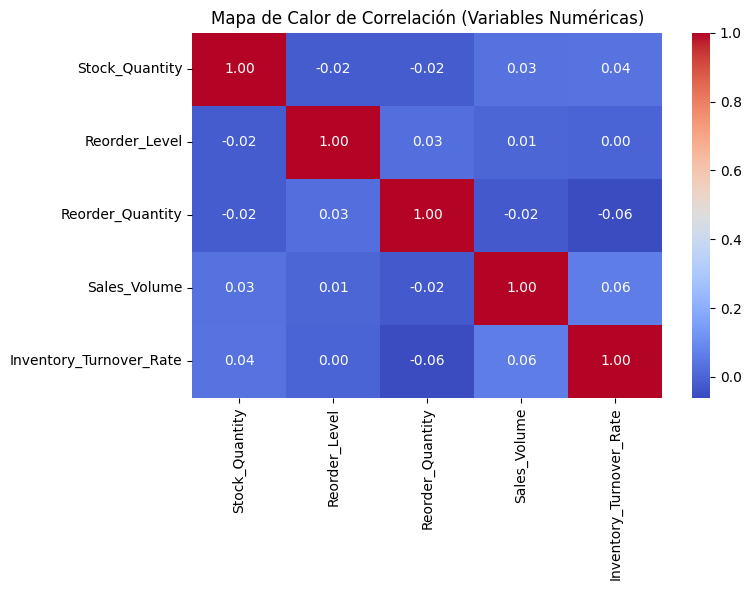

In [ ]:
# Correlación Heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación (Variables Numéricas)')
plt.tight_layout()

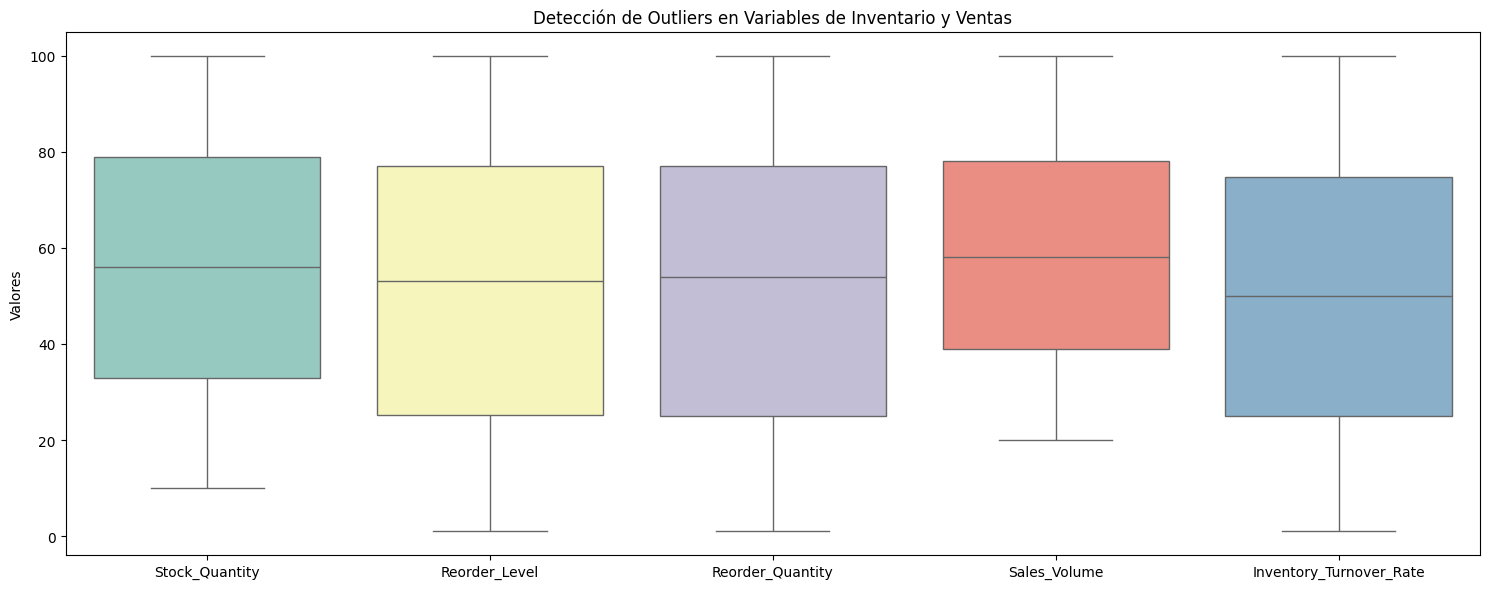

In [ ]:
# Boxplots de variables numéricas para detectar outliers
num_cols = ['Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate']
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[num_cols], palette="Set3")
plt.title('Detección de Outliers en Variables de Inventario y Ventas')
plt.ylabel('Valores')
plt.tight_layout()

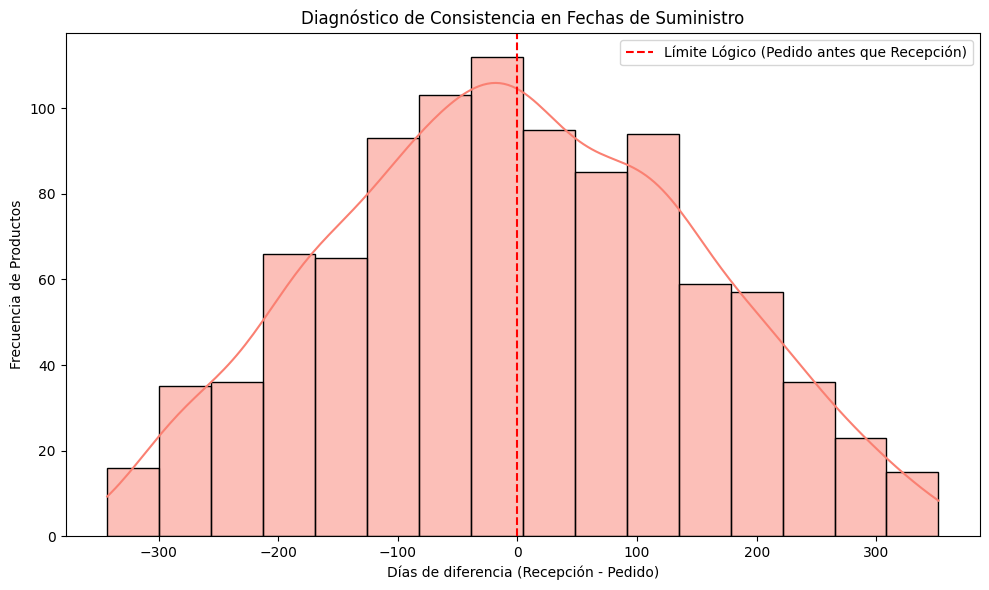

Total de registros analizados: 990
Cantidad de registros inconsistentes encontrados: 514
Porcentaje de error en data original: 51.92%


In [ ]:
df['Date_Received'] = pd.to_datetime(df['Date_Received'])
df['Last_Order_Date'] = pd.to_datetime(df['Last_Order_Date'])

# 2. Calcular el 'Lead Time' observado (Diferencia entre recepción y pedido)
df['Lead_Time_Check'] = (df['Date_Received'] - df['Last_Order_Date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(df['Lead_Time_Check'], kde=True, color='salmon')
plt.axvline(0, color='red', linestyle='--', label='Límite Lógico (Pedido antes que Recepción)')
plt.title('Diagnóstico de Consistencia en Fechas de Suministro')
plt.xlabel('Días de diferencia (Recepción - Pedido)')
plt.ylabel('Frecuencia de Productos')
plt.legend()
plt.tight_layout()
plt.show()

inconsistencias = df[df['Lead_Time_Check'] < 0]
print(f"Total de registros analizados: {len(df)}")
print(f"Cantidad de registros inconsistentes encontrados: {len(inconsistencias)}")
print(f"Porcentaje de error en data original: {(len(inconsistencias)/len(df))*100:.2f}%")

In [ ]:
print("--- PRUEBA DE NORMALIDAD (Shapiro-Wilk) ---")
for col in num_cols:
    stat, p = shapiro(df[col].dropna())
    print(f'Variable: {col}')
    print(f'Estadístico=%.3f, p-valor=%.3f' % (stat, p))
    if p > 0.05:
        print('Interpretación: Probablemente Normal (No se rechaza H0)')
    else:
        print('Interpretación: No es Normal (Se rechaza H0)')
    print('-' * 30)

--- PRUEBA DE NORMALIDAD (Shapiro-Wilk) ---
Variable: Stock_Quantity
Estadístico=0.952, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Reorder_Level
Estadístico=0.952, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Reorder_Quantity
Estadístico=0.946, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Sales_Volume
Estadístico=0.957, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Inventory_Turnover_Rate
Estadístico=0.955, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------


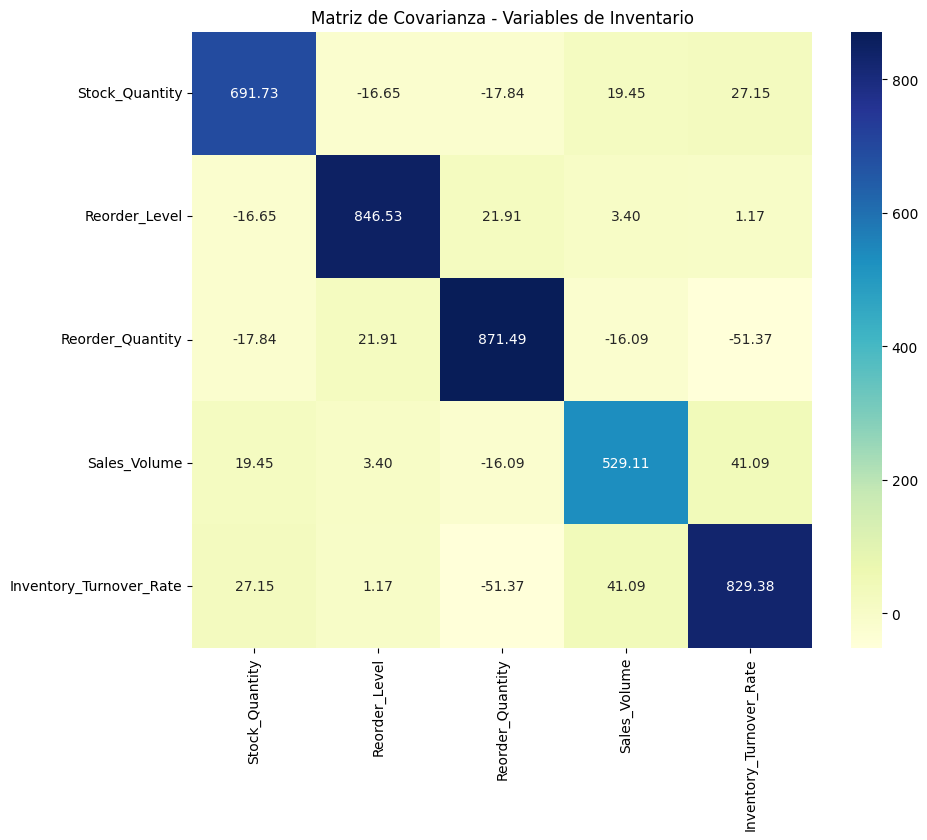

In [ ]:
# Cálculo de la Matriz de Covarianza
cov_matrix = df[num_cols].cov()

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Matriz de Covarianza - Variables de Inventario')
plt.show()

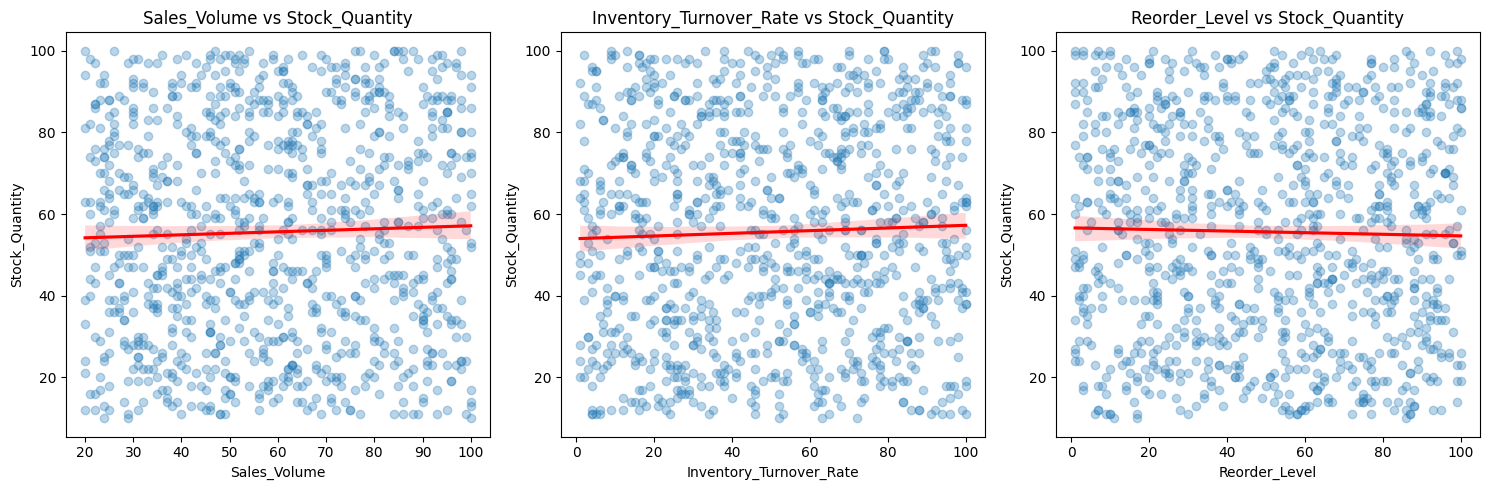

In [ ]:
# Variable objetivo: Stock_Quantity
variables_predictoras = ['Sales_Volume', 'Inventory_Turnover_Rate', 'Reorder_Level']

plt.figure(figsize=(15, 5))
for i, col in enumerate(variables_predictoras, 1):
    plt.subplot(1, 3, i)
    sns.regplot(data=df, x=col, y='Stock_Quantity', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'{col} vs Stock_Quantity')
plt.tight_layout()
plt.show()

#Data Preparation

In [ ]:
# Definimos las columnas que no aportan valor al dataset
# Lista de columnas a eliminar
columnas_irrelevantes = [
    'Product_ID',
    'Unit_Price',
    'Supplier_ID',
    'Supplier_Name',
    'Warehouse_Location'
]

# Eliminamos las columnas del DataFrame
df_clean = df.drop(columns=columnas_irrelevantes)
print(f"Columnas restantes: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

df_clean.info()

Columnas restantes: 12
['Product_Name', 'Catagory', 'Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Date_Received', 'Last_Order_Date', 'Expiration_Date', 'Sales_Volume', 'Inventory_Turnover_Rate', 'Status', 'Lead_Time_Check']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_Name             990 non-null    object        
 1   Catagory                 989 non-null    object        
 2   Stock_Quantity           990 non-null    int64         
 3   Reorder_Level            990 non-null    int64         
 4   Reorder_Quantity         990 non-null    int64         
 5   Date_Received            990 non-null    datetime64[ns]
 6   Last_Order_Date          990 non-null    datetime64[ns]
 7   Expiration_Date          990 non-null    object        
 8   Sales_Volume             990 non-null    int64

In [ ]:
# Diccionario de nombres antiguos a nuevos
nuevos_nombres = {
    'Product_Name': 'Producto',
    'Catagory': 'Categoria',
    'Stock_Quantity': 'Stock_Actual',
    'Reorder_Level': 'Punto_Reorden',
    'Reorder_Quantity': 'Cantidad_Pedido',
    'Date_Received': 'Fecha_Recepcion',
    'Last_Order_Date': 'Ultimo_Pedido',
    'Expiration_Date': 'Fecha_Vencimiento',
    'Sales_Volume': 'Volumen_Consumo',
    'Inventory_Turnover_Rate': 'Tasa_Rotacion',
    'Status': 'Estado'
}

# Renombrar columnas
df_clean = df_clean.rename(columns=nuevos_nombres)

# Verificar el cambio
df_clean.head()

,Producto,Categoria,Stock_Actual,Punto_Reorden,Cantidad_Pedido,Fecha_Recepcion,Ultimo_Pedido,Fecha_Vencimiento,Volumen_Consumo,Tasa_Rotacion,Estado,Lead_Time_Check
0,Sushi Rice,Grains & Pulses,22,72,70,2024-08-16,2024-06-29,9/19/2024,32,19,Discontinued,48
1,Arabica Coffee,Beverages,45,77,2,2024-11-01,2024-05-29,5/8/2024,85,1,Discontinued,156
2,Black Rice,Grains & Pulses,30,38,83,2024-08-03,2024-06-10,9/22/2024,31,34,Backordered,54
3,Long Grain Rice,Grains & Pulses,12,59,62,2024-12-08,2025-02-19,4/17/2024,95,99,Active,-73
4,Plum,Fruits & Vegetables,37,30,74,2024-07-03,2024-10-11,10/5/2024,62,25,Backordered,-100


In [ ]:
# Imputar el valor nulo en Categoria
df_clean['Categoria'] = df_clean['Categoria'].fillna('Otros')

# Convertir columnas a formato datetime
fechas = ['Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento']
for col in fechas:
    df_clean[col] = pd.to_datetime(df_clean[col])

# Verificar que no haya nulos nuevos tras la conversión
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Producto           990 non-null    object        
 1   Categoria          990 non-null    object        
 2   Stock_Actual       990 non-null    int64         
 3   Punto_Reorden      990 non-null    int64         
 4   Cantidad_Pedido    990 non-null    int64         
 5   Fecha_Recepcion    990 non-null    datetime64[ns]
 6   Ultimo_Pedido      990 non-null    datetime64[ns]
 7   Fecha_Vencimiento  990 non-null    datetime64[ns]
 8   Volumen_Consumo    990 non-null    int64         
 9   Tasa_Rotacion      990 non-null    int64         
 10  Estado             990 non-null    object        
 11  Lead_Time_Check    990 non-null    int64         
dtypes: datetime64[ns](3), int64(6), object(3)
memory usage: 92.9+ KB


In [ ]:
def clasificar_vencimiento(dias):
    if dias < 0: return 'Vencido'
    if dias <= 15: return 'Crítico (15 días)'
    if dias <= 30: return 'Próximo (30 días)'
    return 'Seguro'

# Sumar 2 años a todas las columnas de fecha para que sea coherente al 2026
for col in ['Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento']:
    df_clean[col] = df_clean[col] + pd.Timedelta(days=730)

# Corregir la lógica de Pedido vs Recepción
# Definimos que el "Ultimo_Pedido" ocurrió siempre 7 días antes de la "Fecha_Recepcion"
df_clean['Ultimo_Pedido'] = df_clean['Fecha_Recepcion'] - pd.Timedelta(days=7)

# Recalcular los días para el vencimiento basándonos en hoy (Abril 2026)
fecha_hoy = pd.to_datetime('2026-04-29')
df_clean['Dias_para_Vencimiento'] = (df_clean['Fecha_Vencimiento'] - fecha_hoy).dt.days

# Actualizar el Estado de Vencimiento con los nuevos datos
df_clean['Estado_Vencimiento'] = df_clean['Dias_para_Vencimiento'].apply(clasificar_vencimiento)

df_clean[['Producto', 'Ultimo_Pedido', 'Fecha_Recepcion', 'Fecha_Vencimiento', 'Estado_Vencimiento']].head()

,Producto,Ultimo_Pedido,Fecha_Recepcion,Fecha_Vencimiento,Estado_Vencimiento
0,Sushi Rice,2026-08-09,2026-08-16,2026-09-19,Seguro
1,Arabica Coffee,2026-10-25,2026-11-01,2026-05-08,Crítico (15 días)
2,Black Rice,2026-07-27,2026-08-03,2026-09-22,Seguro
3,Long Grain Rice,2026-12-01,2026-12-08,2026-04-17,Vencido
4,Plum,2026-06-26,2026-07-03,2026-10-05,Seguro


In [ ]:
# --- 30 INSUMOS MÉDICOS CRÍTICOS ---
insumos_medicos = [
    ('Metotrexato 500mg', 'Oncológicos'), ('Ciclofosfamida 1g', 'Oncológicos'),
    ('Vincristina 1mg', 'Oncológicos'), ('Doxorrubicina 50mg', 'Oncológicos'),
    ('Ondansetrón 8mg', 'Antieméticos'), ('Dexametasona 4mg', 'Antieméticos'),
    ('Suero Fisiológico 500ml', 'Soporte'), ('Dextrosa al 5%', 'Soporte'),
    ('Cloruro de Potasio 20%', 'Soporte'), ('Catéter Endovenoso 24G', 'Insumos'),
    ('Catéter Port-a-Cath', 'Insumos'), ('Jeringa 5ml', 'Insumos'),
    ('Equipo de Venoclisis', 'Insumos'), ('Llave de 3 vías', 'Insumos'),
    ('Pediasure Plus 200ml', 'Nutrición'), ('Fórmula Polimérica', 'Nutrición'),
    ('Espesante de Alimentos', 'Nutrición'), ('Mascarilla N95 Pediátrica', 'Higiene'),
    ('Alcohol en Gel 70%', 'Higiene'), ('Guantes Estériles', 'Higiene'),
    ('Jabón Clorhexidina', 'Higiene'), ('Tubo Vacutainer (Rojo)', 'Laboratorio'),
    ('Tubo Vacutainer (Lila)', 'Laboratorio'), ('Placas de Rayos X', 'Imágenes'),
    ('Crema de Hidrocortisona', 'Tópicos'), ('Gasas Estériles', 'Curación'),
    ('Esparadrapo Micropore', 'Curación'), ('Paracetamol Jarabe', 'Analgesicos'),
    ('Ibuprofeno Pediátrico', 'Analgesicos'), ('Ceftriaxona 1g', 'Antibióticos')
]

# --- GENERACIÓN DE 500 FILAS SINTÉTICAS ---
np.random.seed(42)
data_medica = []
fecha_hoy = pd.to_datetime('2026-04-29')

for i in range(500):
    producto, categoria = insumos_medicos[np.random.randint(len(insumos_medicos))]

    # Lógica de Criticidad: Los Oncológicos y Soporte tienen stock más volátil
    if categoria in ['Oncológicos', 'Soporte']:
        stock_actual = np.random.randint(5, 60)
        vol_consumo = np.random.randint(40, 110)
    else:
        stock_actual = np.random.randint(30, 150)
        vol_consumo = np.random.randint(10, 70)

    punto_reorden = int(vol_consumo * 0.6)

    # Fechas 2026 con lógica corregida (Pedido siempre antes que Recepción)
    fecha_rec = pd.to_datetime('2026-01-10') + pd.Timedelta(days=np.random.randint(0, 120))
    lead_time = np.random.randint(3, 12)
    ultimo_pedido = fecha_rec - pd.Timedelta(days=lead_time)
    fecha_vencimiento = fecha_rec + pd.Timedelta(days=np.random.randint(180, 720))
    dias_venc = (fecha_vencimiento - fecha_hoy).dt.days if isinstance(fecha_vencimiento, pd.Series) else (fecha_vencimiento - fecha_hoy).days

    data_medica.append({
        'Producto': producto,
        'Categoria': categoria,
        'Stock_Actual': stock_actual,
        'Punto_Reorden': punto_reorden,
        'Cantidad_Pedido': np.random.randint(50, 200),
        'Fecha_Recepcion': fecha_rec,
        'Ultimo_Pedido': ultimo_pedido,
        'Fecha_Vencimiento': fecha_vencimiento,
        'Volumen_Consumo': vol_consumo,
        'Tasa_Rotacion': round(vol_consumo / (stock_actual + 1), 2),
        'Estado': 'Active',
        'Dias_para_Vencimiento': dias_venc,
        'Estado_Vencimiento': clasificar_vencimiento(dias_venc)
    })

# Crear DataFrame sintético
df_medico_sintetico = pd.DataFrame(data_medica)

# Concatenar con el dataset de abarrotes limpio
df_final = pd.concat([df_clean, df_medico_sintetico], ignore_index=True)
print(f"Dataset Unificado ALDIMI: {len(df_final)} registros.")
print(f"Columnas finales: {df_final.columns.tolist()}")

Dataset Unificado ALDIMI: 1490 registros.
Columnas finales: ['Producto', 'Categoria', 'Stock_Actual', 'Punto_Reorden', 'Cantidad_Pedido', 'Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento', 'Volumen_Consumo', 'Tasa_Rotacion', 'Estado', 'Lead_Time_Check', 'Dias_para_Vencimiento', 'Estado_Vencimiento']


In [ ]:
# Exportación csv del dataset final
nombre_archivo = 'inventario_limpio.csv'
df_final.to_csv(nombre_archivo, index=False)

---
# Hito 2: Preparación Completa y Modelo Baseline
## Predicción de Demanda y Logística — ALDIMI Predict



In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías del modelado cargadas")


✅ Librerías del modelado cargadas


In [ ]:
df_model = df_final.copy()

# Días hasta quiebre de stock estimado
# Asumimos que Volumen_Consumo es mensual → consumo diario = Volumen_Consumo / 30
df_model['Consumo_Diario']     = df_model['Volumen_Consumo'] / 30
df_model['Dias_hasta_Quiebre'] = (df_model['Stock_Actual'] / df_model['Consumo_Diario']).round(1)

# Proyección de demanda a 7 y 14 días
df_model['Demanda_7_dias']  = (df_model['Consumo_Diario'] * 7).round(1)
df_model['Demanda_14_dias'] = (df_model['Consumo_Diario'] * 14).round(1)

# Indicador de riesgo de quiebre de stock
df_model['Alerta_7_dias']  = (df_model['Dias_hasta_Quiebre'] <= 7).astype(int)
df_model['Alerta_14_dias'] = (df_model['Dias_hasta_Quiebre'] <= 14).astype(int)

# Ratio stock / punto de reorden
df_model['Ratio_Stock_Reorden'] = (df_model['Stock_Actual'] / (df_model['Punto_Reorden'] + 1)).round(3)

# Urgencia de reabastecimiento (stock por debajo del punto de reorden)
df_model['Necesita_Reorden'] = (df_model['Stock_Actual'] <= df_model['Punto_Reorden']).astype(int)

print("=== Features derivadas creadas ===")
print(df_model[['Producto','Stock_Actual','Consumo_Diario','Dias_hasta_Quiebre',
                'Demanda_7_dias','Demanda_14_dias','Alerta_7_dias',
                'Alerta_14_dias','Ratio_Stock_Reorden']].head(6).to_string())

print(f"\nProductos con alerta a 7 días  : {df_model['Alerta_7_dias'].sum():>4} ({df_model['Alerta_7_dias'].mean()*100:.1f}%)")
print(f"Productos con alerta a 14 días : {df_model['Alerta_14_dias'].sum():>4} ({df_model['Alerta_14_dias'].mean()*100:.1f}%)")


=== Features derivadas creadas ===
            Producto  Stock_Actual  Consumo_Diario  Dias_hasta_Quiebre  Demanda_7_dias  Demanda_14_dias  Alerta_7_dias  Alerta_14_dias  Ratio_Stock_Reorden
0         Sushi Rice            22        1.066667                20.6             7.5             14.9              0               0                0.301
1     Arabica Coffee            45        2.833333                15.9            19.8             39.7              0               0                0.577
2         Black Rice            30        1.033333                29.0             7.2             14.5              0               0                0.769
3    Long Grain Rice            12        3.166667                 3.8            22.2             44.3              1               1                0.200
4               Plum            37        2.066667                17.9            14.5             28.9              0               0                1.194
5  All-Purpose Flour         

In [ ]:
# 2.1 Label Encoding de variables categóricas
le_cat   = LabelEncoder()
le_est   = LabelEncoder()
le_venc  = LabelEncoder()

df_model['Categoria_cod']= le_cat.apply_fit(df_model['Categoria'])   if False else le_cat.fit_transform(df_model['Categoria'])
df_model['Estado_cod']= le_est.fit_transform(df_model['Estado'].fillna('Unknown'))
df_model['Estado_Vencimiento_cod'] = le_venc.fit_transform(df_model['Estado_Vencimiento'])

print("=== Encoding de variables categóricas ===")
print(f"Categoria          : {dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_)))}")
print(f"Estado_Vencimiento : {dict(zip(le_venc.classes_, le_venc.transform(le_venc.classes_)))}")


=== Encoding de variables categóricas ===
Categoria          : {'Analgesicos': np.int64(0), 'Antibióticos': np.int64(1), 'Antieméticos': np.int64(2), 'Bakery': np.int64(3), 'Beverages': np.int64(4), 'Curación': np.int64(5), 'Dairy': np.int64(6), 'Fruits & Vegetables': np.int64(7), 'Grains & Pulses': np.int64(8), 'Higiene': np.int64(9), 'Imágenes': np.int64(10), 'Insumos': np.int64(11), 'Laboratorio': np.int64(12), 'Nutrición': np.int64(13), 'Oils & Fats': np.int64(14), 'Oncológicos': np.int64(15), 'Otros': np.int64(16), 'Seafood': np.int64(17), 'Soporte': np.int64(18), 'Tópicos': np.int64(19)}
Estado_Vencimiento : {'Crítico (15 días)': np.int64(0), 'Próximo (30 días)': np.int64(1), 'Seguro': np.int64(2), 'Vencido': np.int64(3)}


In [ ]:
# 2.2 Selección de features y target
FEATURES = [
    'Stock_Actual',
    'Punto_Reorden',
    'Cantidad_Pedido',
    'Tasa_Rotacion',
    'Dias_para_Vencimiento',
    'Ratio_Stock_Reorden',
    'Necesita_Reorden',
    'Categoria_cod',
    'Estado_cod',
    'Estado_Vencimiento_cod',
]

TARGET = 'Volumen_Consumo'   # Variable objetivo: demanda del producto

X = df_model[FEATURES].fillna(0)
y = df_model[TARGET]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target            : {TARGET}")
print(f"Shape X           : {X.shape}")
print(f"\nEstadísticas del target (Volumen_Consumo):")
print(y.describe().round(2).to_string())


Features (10): ['Stock_Actual', 'Punto_Reorden', 'Cantidad_Pedido', 'Tasa_Rotacion', 'Dias_para_Vencimiento', 'Ratio_Stock_Reorden', 'Necesita_Reorden', 'Categoria_cod', 'Estado_cod', 'Estado_Vencimiento_cod']
Target            : Volumen_Consumo
Shape X           : (1490, 10)

Estadísticas del target (Volumen_Consumo):
count    1490.00
mean       55.60
std        23.62
min        10.00
25%        36.00
50%        54.00
75%        73.00
max       109.00


In [ ]:
# 2.3 Normalización Min-Max
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print("Variables normalizadas (Min-Max Scaling):")
print(X_scaled.describe().round(3).to_string())


Variables normalizadas (Min-Max Scaling):
       Stock_Actual  Punto_Reorden  Cantidad_Pedido  Tasa_Rotacion  Dias_para_Vencimiento  Ratio_Stock_Reorden  Necesita_Reorden  Categoria_cod  Estado_cod  Estado_Vencimiento_cod
count      1490.000       1490.000         1490.000       1490.000               1490.000             1490.000          1490.000       1490.000    1490.000                1490.000
mean          0.394          0.432            0.388          0.337                  0.347                0.055             0.380          0.463       0.333                   0.674
std           0.227          0.275            0.253          0.330                  0.232                0.090             0.486          0.241       0.409                   0.176
min           0.000          0.000            0.000          0.000                  0.000                0.000             0.000          0.000       0.000                   0.000
25%           0.215          0.212            0.192       

## 3. Train / Test (80 / 20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print(f"Conjunto de entrenamiento : {X_train.shape[0]:>5} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de prueba        : {X_test.shape[0]:>5} registros ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nMedia target — train : {y_train.mean():.2f}")
print(f"Media target — test  : {y_test.mean():.2f}")
print("→ Distribución similar entre train y test ✅")


Conjunto de entrenamiento :  1192 registros (80%)
Conjunto de prueba        :   298 registros (20%)

Media target — train : 55.48
Media target — test  : 56.06
→ Distribución similar entre train y test ✅


## 4. Modelos Baseline
### Variable objetivo: Volumen_Consumo (demanda mensual del producto)
La predicción de demanda a 7 y 14 días se deriva directamente:
- Demanda_7_días = Volumen_Consumo_predicho / 30 × 7
- Demanda_14_días = Volumen_Consumo_predicho / 30 × 14


In [ ]:
# 4.1 Entrenamiento de modelos baseline
modelos = {
    'Regresión Lineal (baseline)': LinearRegression(),
    'Árbol de Decisión'          : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'              : RandomForestRegressor(n_estimators=100, max_depth=6,
                                                         random_state=42, n_jobs=-1),
}

resultados = {}
media_y = y_test.mean()

print(f"{'Modelo':<35} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAE%':>8}  Estado")
print("─" * 80)

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred  = modelo.predict(X_test)
    mae   = mean_absolute_error(y_test, pred)
    rmse  = mean_squared_error(y_test, pred) ** 0.5
    r2    = r2_score(y_test, pred)
    mape  = mae / media_y * 100
    ok    = "✅ Cumple" if mape < 15 else "⚠️  Revisar"
    resultados[nombre] = {'MAE': round(mae,3), 'RMSE': round(rmse,3),
                           'R²': round(r2,3), 'MAE%': round(mape,1),
                           'pred': pred}
    print(f"{nombre:<35} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f} {mape:>7.1f}%  {ok}")

print(f"\nMedia del target en test : {media_y:.2f} unidades")
print(f"Criterio de éxito        : MAE% < 15% → MAE < {media_y*0.15:.2f} unidades")


Modelo                                   MAE     RMSE       R²     MAE%  Estado
────────────────────────────────────────────────────────────────────────────────
Regresión Lineal (baseline)           18.407   21.985    0.049    32.8%  ⚠️  Revisar
Árbol de Decisión                     14.627   20.018    0.211    26.1%  ⚠️  Revisar
Random Forest                         13.651   18.588    0.320    24.4%  ⚠️  Revisar

Media del target en test : 56.06 unidades
Criterio de éxito        : MAE% < 15% → MAE < 8.41 unidades


## 5. Evaluación y Visualizaciones

In [ ]:
# 5.1 Comparativa de metricas
df_res = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'pred'}
                        for k, v in resultados.items()}).T.sort_values('MAE%')

print("=== Tabla comparativa de modelos ===")
display(df_res)


=== Tabla comparativa de modelos ===


,MAE,RMSE,R²,MAE%
Random Forest,13.651,18.588,0.320,24.4
Árbol de Decisión,14.627,20.018,0.211,26.1
Regresión Lineal (baseline),18.407,21.985,0.049,32.8


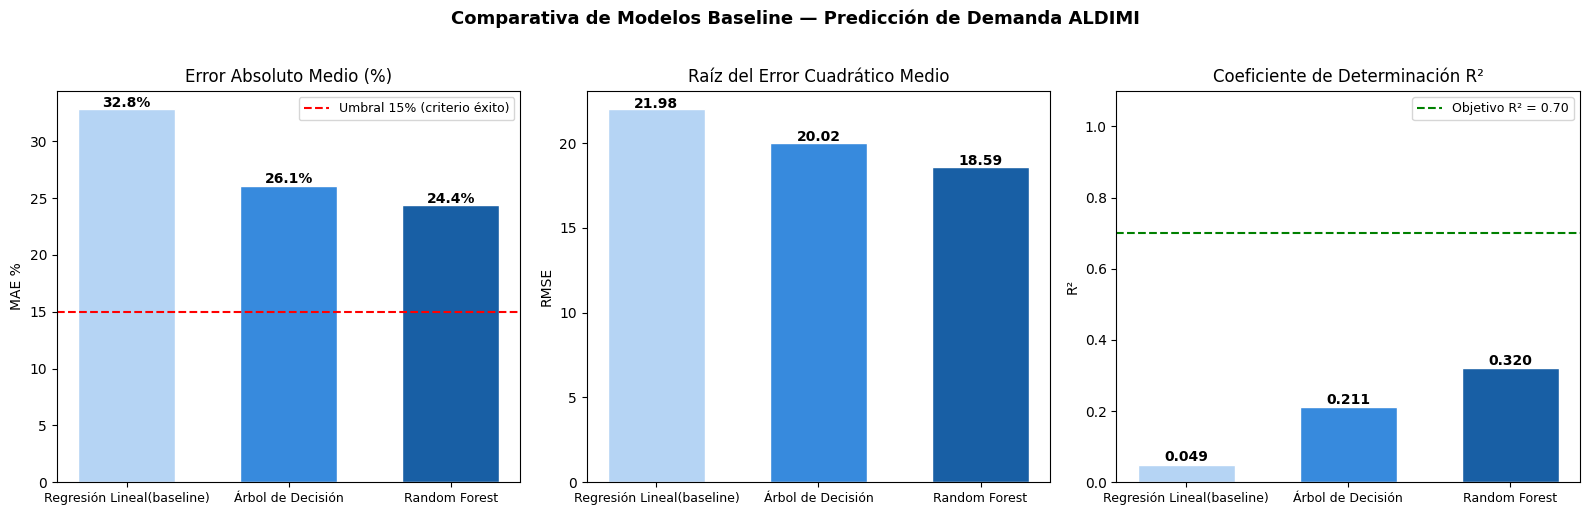

Figura guardada: comparativa_modelos.png


In [ ]:
# 5.2 Grafica comparativa de metricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
nombres   = list(resultados.keys())
colores   = ['#B5D4F4', '#378ADD', '#185FA5']

# MAE%
mae_vals = [resultados[n]['MAE%'] for n in nombres]
bars = axes[0].bar(range(len(nombres)), mae_vals, color=colores, edgecolor='white', width=0.6)
axes[0].axhline(15, color='red', linestyle='--', lw=1.5, label='Umbral 15% (criterio éxito)')
axes[0].set_xticks(range(len(nombres)))
axes[0].set_xticklabels([n.replace(' (','(') for n in nombres], fontsize=9)
axes[0].set_ylabel('MAE %'); axes[0].set_title('Error Absoluto Medio (%)'); axes[0].legend(fontsize=9)
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# RMSE
rmse_vals = [resultados[n]['RMSE'] for n in nombres]
bars2 = axes[1].bar(range(len(nombres)), rmse_vals, color=colores, edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(nombres)))
axes[1].set_xticklabels([n.replace(' (','(') for n in nombres], fontsize=9)
axes[1].set_ylabel('RMSE'); axes[1].set_title('Raíz del Error Cuadrático Medio')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# R²
r2_vals = [resultados[n]['R²'] for n in nombres]
bars3 = axes[2].bar(range(len(nombres)), r2_vals, color=colores, edgecolor='white', width=0.6)
axes[2].axhline(0.7, color='green', linestyle='--', lw=1.5, label='Objetivo R² = 0.70')
axes[2].set_xticks(range(len(nombres)))
axes[2].set_xticklabels([n.replace(' (','(') for n in nombres], fontsize=9)
axes[2].set_ylim(0, 1.1); axes[2].set_ylabel('R²'); axes[2].set_title('Coeficiente de Determinación R²')
axes[2].legend(fontsize=9)
for bar, val in zip(bars3, r2_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparativa de Modelos Baseline — Predicción de Demanda ALDIMI',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: comparativa_modelos.png")


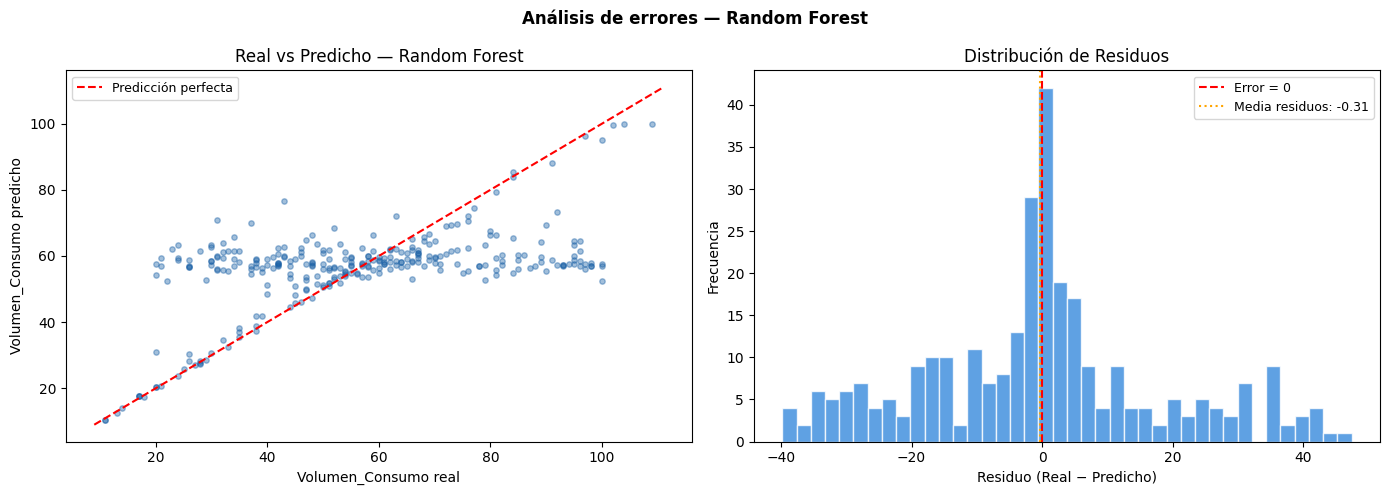

In [ ]:
# 5.3 Predicción vs Real — mejor modelo
mejor_nombre = min(resultados, key=lambda n: resultados[n]['MAE%'])
pred_mejor   = resultados[mejor_nombre]['pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicho
axes[0].scatter(y_test, pred_mejor, alpha=0.4, s=15, color='#185FA5')
lim = [y_test.min()-2, y_test.max()+2]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Volumen_Consumo real'); axes[0].set_ylabel('Volumen_Consumo predicho')
axes[0].set_title(f'Real vs Predicho — {mejor_nombre}'); axes[0].legend(fontsize=9)

# Distribución del error (residuos)
residuos = y_test.values - pred_mejor
axes[1].hist(residuos, bins=40, color='#378ADD', alpha=0.8, edgecolor='white')
axes[1].axvline(0,   color='red',    linestyle='--', lw=1.5, label='Error = 0')
axes[1].axvline(residuos.mean(), color='orange', linestyle=':', lw=1.5,
                label=f'Media residuos: {residuos.mean():.2f}')
axes[1].set_xlabel('Residuo (Real − Predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos'); axes[1].legend(fontsize=9)

plt.suptitle(f'Análisis de errores — {mejor_nombre}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()


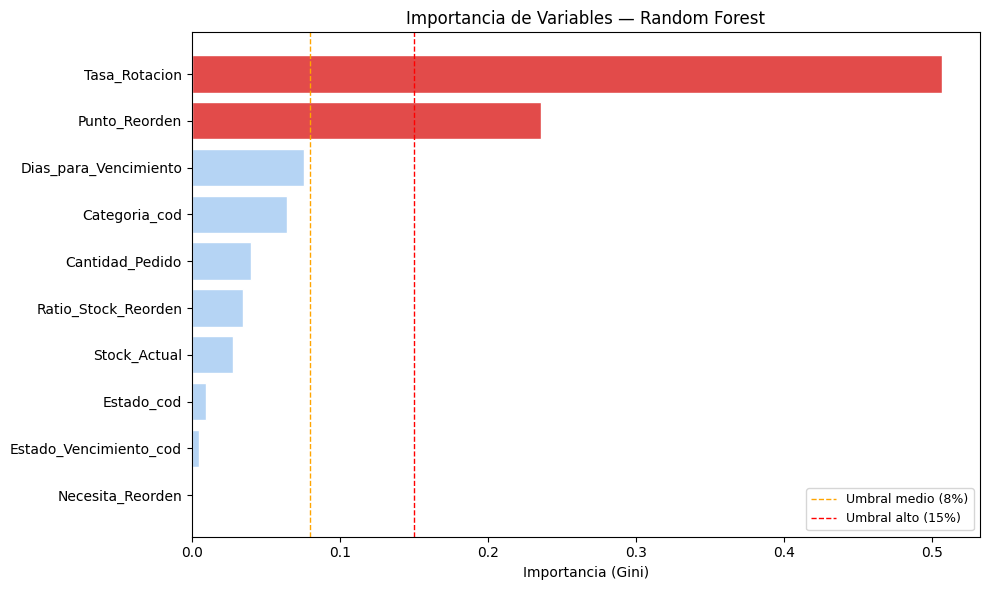


Top 5 features más importantes:
Tasa_Rotacion            0.507015
Punto_Reorden            0.235959
Dias_para_Vencimiento    0.075532
Categoria_cod            0.063971
Cantidad_Pedido          0.039702


In [ ]:
# 5.4 Feature Importance (Random Forest)
rf_model = modelos['Random Forest']
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colores_imp = ['#E24B4A' if v > 0.15 else '#378ADD' if v > 0.08 else '#B5D4F4'
               for v in importancias.values]
ax.barh(importancias.index, importancias.values, color=colores_imp, edgecolor='white')
ax.axvline(0.08, color='orange', linestyle='--', lw=1, label='Umbral medio (8%)')
ax.axvline(0.15, color='red',    linestyle='--', lw=1, label='Umbral alto (15%)')
ax.set_xlabel('Importancia (Gini)'); ax.set_title('Importancia de Variables — Random Forest')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features más importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())


## 6. Proyecciones a 7 y 14 días

In [ ]:
#  6.1 Predicción de demanda a 7 y 14 dias
# Usar el mejor modelo para predecir Volumen_Consumo de TODOS los productos
mejor_modelo = modelos[mejor_nombre]
X_all_scaled = pd.DataFrame(scaler.transform(X), columns=FEATURES)
pred_todos   = mejor_modelo.predict(X_all_scaled)

df_predicciones = df_model[['Producto','Categoria','Stock_Actual',
                             'Punto_Reorden','Volumen_Consumo']].copy()
df_predicciones['Consumo_Predicho_Mensual'] = pred_todos.round(1)
df_predicciones['Demanda_Predicha_7d']      = (pred_todos / 30 * 7).round(1)
df_predicciones['Demanda_Predicha_14d']     = (pred_todos / 30 * 14).round(1)
df_predicciones['Dias_hasta_Quiebre']       = (df_model['Stock_Actual'] /
                                                (pred_todos / 30 + 1e-6)).round(1)
df_predicciones['ALERTA_7d']  = (df_predicciones['Dias_hasta_Quiebre'] <= 7).map({True:'🔴 CRÍTICO', False:'✅ OK'})
df_predicciones['ALERTA_14d'] = (df_predicciones['Dias_hasta_Quiebre'] <= 14).map({True:'🟡 RIESGO', False:'✅ OK'})

print("=== Predicciones de Demanda a 7 y 14 días ===")
print(f"Productos en estado CRÍTICO (≤7 días)  : {(df_predicciones['ALERTA_7d']=='🔴 CRÍTICO').sum()}")
print(f"Productos en estado RIESGO (≤14 días)  : {(df_predicciones['ALERTA_14d']=='🟡 RIESGO').sum()}")
print()


# Top 10 productos mas criticos
criticos = df_predicciones.sort_values('Dias_hasta_Quiebre').head(10)
display(criticos[['Producto','Categoria','Stock_Actual','Demanda_Predicha_7d',
                  'Demanda_Predicha_14d','Dias_hasta_Quiebre','ALERTA_7d','ALERTA_14d']])


=== Predicciones de Demanda a 7 y 14 días ===
Productos en estado CRÍTICO (≤7 días)  : 67
Productos en estado RIESGO (≤14 días)  : 266



,Producto,Categoria,Stock_Actual,Demanda_Predicha_7d,Demanda_Predicha_14d,Dias_hasta_Quiebre,ALERTA_7d,ALERTA_14d
1169,Dextrosa al 5%,Soporte,5,19.9,39.8,1.8,🔴 CRÍTICO,🟡 RIESGO
1255,Suero Fisiológico 500ml,Soporte,6,17.2,34.3,2.4,🔴 CRÍTICO,🟡 RIESGO
1065,Suero Fisiológico 500ml,Soporte,8,21.8,43.6,2.6,🔴 CRÍTICO,🟡 RIESGO
1202,Ciclofosfamida 1g,Oncológicos,7,16.8,33.6,2.9,🔴 CRÍTICO,🟡 RIESGO
1408,Ciclofosfamida 1g,Oncológicos,10,22.5,44.9,3.1,🔴 CRÍTICO,🟡 RIESGO
1264,Cloruro de Potasio 20%,Soporte,7,15.7,31.3,3.1,🔴 CRÍTICO,🟡 RIESGO
1167,Suero Fisiológico 500ml,Soporte,7,15.7,31.4,3.1,🔴 CRÍTICO,🟡 RIESGO
1032,Dextrosa al 5%,Soporte,11,23.1,46.1,3.3,🔴 CRÍTICO,🟡 RIESGO
1425,Metotrexato 500mg,Oncológicos,8,15.2,30.5,3.7,🔴 CRÍTICO,🟡 RIESGO
1485,Doxorrubicina 50mg,Oncológicos,9,17.1,34.2,3.7,🔴 CRÍTICO,🟡 RIESGO


## 7. Dashboard Preliminar

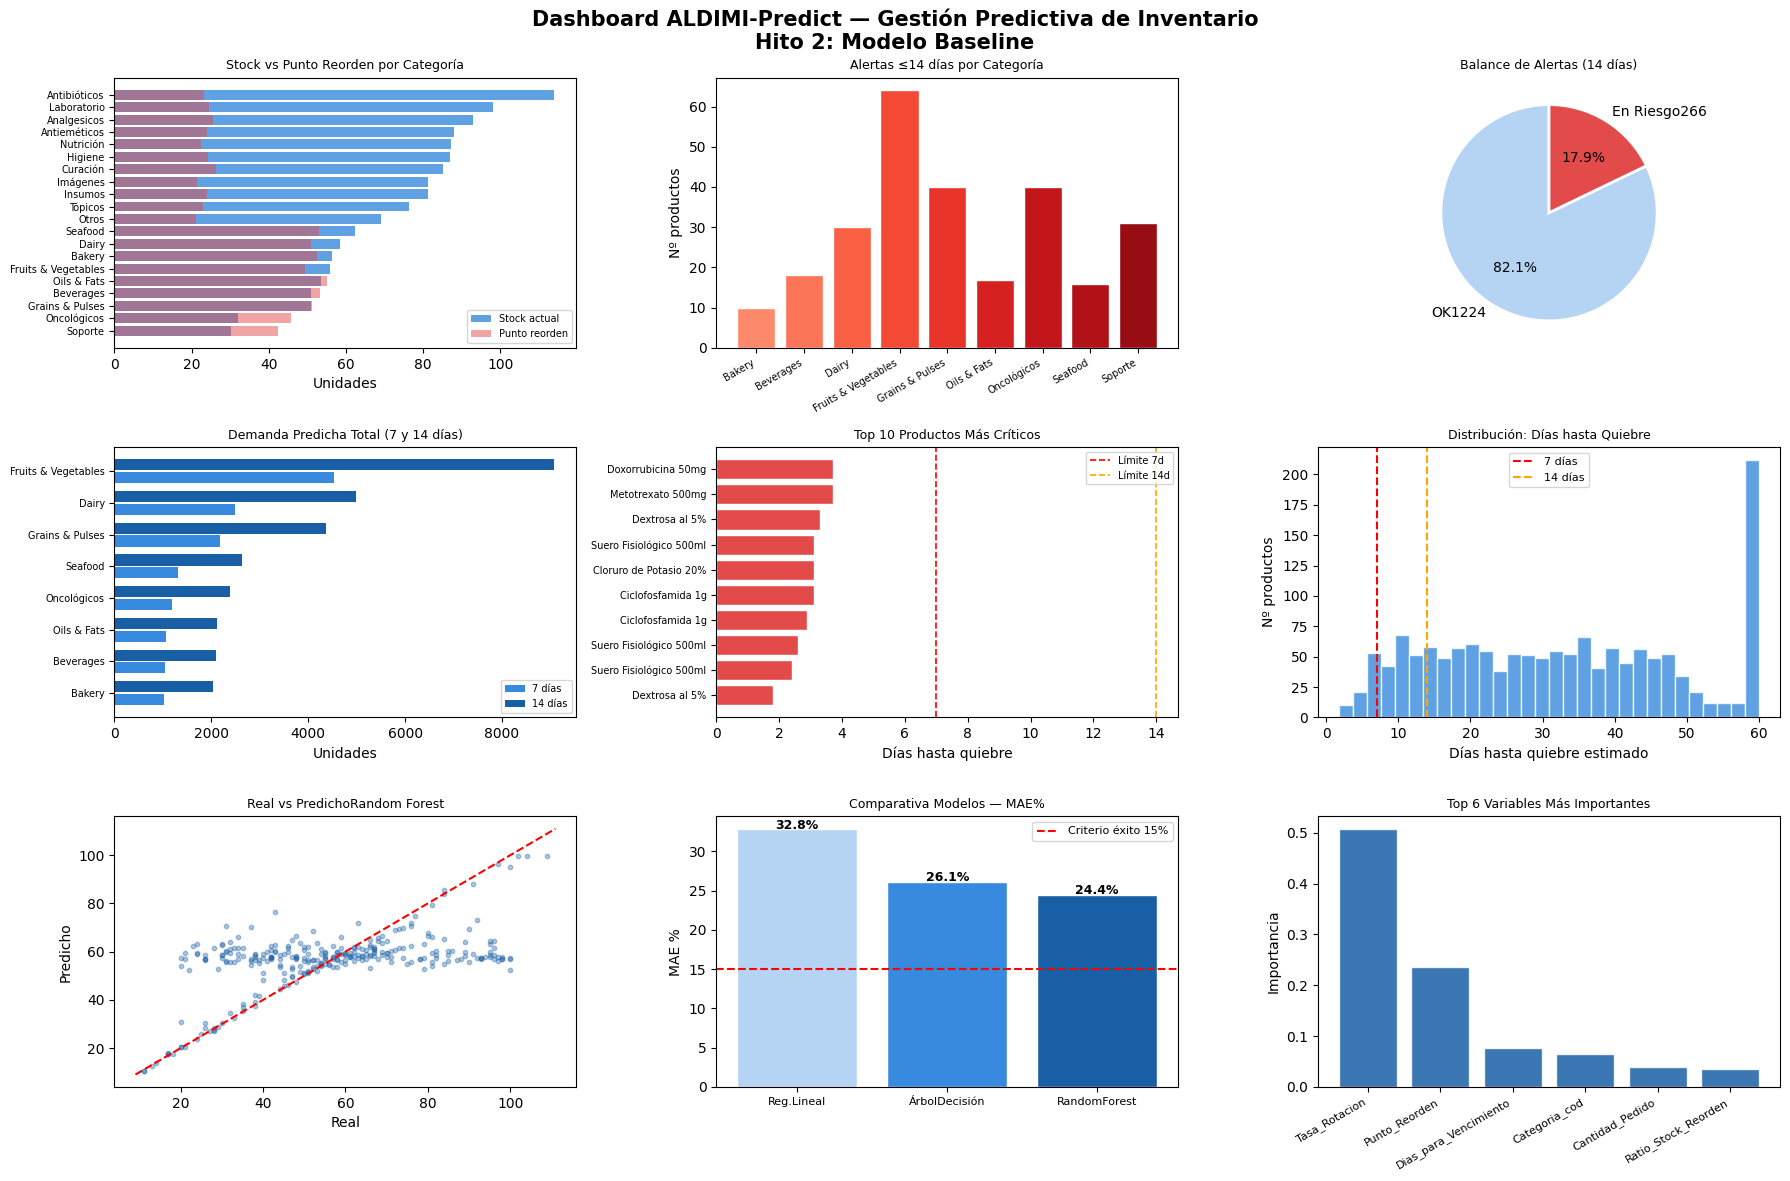

✅ Dashboard guardado: dashboard_hito2_aldimi.png


In [ ]:
# 7.1 Dashboard de Gestión de Inventari
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard ALDIMI-Predict — Gestión Predictiva de Inventario\nHito 2: Modelo Baseline',
             fontsize=15, fontweight='bold', y=0.98)

#Panel 1: Estado del stock por categoria
ax1 = fig.add_subplot(3, 3, 1)
stock_cat = df_predicciones.groupby('Categoria').agg(
    Stock_Promedio=('Stock_Actual','mean'),
    Punto_Reorden_Prom=('Punto_Reorden','mean')
).sort_values('Stock_Promedio')
x_pos = range(len(stock_cat))
ax1.barh(x_pos, stock_cat['Stock_Promedio'], color='#378ADD', alpha=0.8, label='Stock actual')
ax1.barh(x_pos, stock_cat['Punto_Reorden_Prom'], color='#E24B4A', alpha=0.5, label='Punto reorden')
ax1.set_yticks(x_pos); ax1.set_yticklabels(stock_cat.index, fontsize=7)
ax1.set_xlabel('Unidades'); ax1.set_title('Stock vs Punto Reorden por Categoría', fontsize=9)
ax1.legend(fontsize=7)

# Panel 2: Alertas por categoria
ax2 = fig.add_subplot(3, 3, 2)
alertas_cat = df_predicciones[df_predicciones['ALERTA_14d']=='🟡 RIESGO'].groupby('Categoria').size()
if len(alertas_cat) > 0:
    colors_a = plt.cm.Reds(np.linspace(0.4, 0.9, len(alertas_cat)))
    ax2.bar(range(len(alertas_cat)), alertas_cat.values, color=colors_a, edgecolor='white')
    ax2.set_xticks(range(len(alertas_cat)))
    ax2.set_xticklabels(alertas_cat.index, rotation=30, ha='right', fontsize=7)
ax2.set_ylabel('Nº productos'); ax2.set_title('Alertas ≤14 días por Categoría', fontsize=9)

# Panel 3: Pie balance alertas
ax3 = fig.add_subplot(3, 3, 3)
n_ok  = (df_predicciones['ALERTA_14d'] == '✅ OK').sum()
n_rie = (df_predicciones['ALERTA_14d'] == '🟡 RIESGO').sum()
ax3.pie([n_ok, n_rie], labels=[f'OK{n_ok}', f'En Riesgo{n_rie}'],
        colors=['#B5D4F4','#E24B4A'], autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax3.set_title('Balance de Alertas (14 días)', fontsize=9)

# Panel 4: Demanda predicha 7 y 14 días — top categoria
ax4 = fig.add_subplot(3, 3, 4)
dem_cat = df_predicciones.groupby('Categoria').agg(
    d7=('Demanda_Predicha_7d','sum'),
    d14=('Demanda_Predicha_14d','sum')
).sort_values('d14', ascending=True).tail(8)
x4 = range(len(dem_cat))
ax4.barh([i-0.2 for i in x4], dem_cat['d7'],  height=0.35, color='#378ADD', label='7 días')
ax4.barh([i+0.2 for i in x4], dem_cat['d14'], height=0.35, color='#185FA5', label='14 días')
ax4.set_yticks(x4); ax4.set_yticklabels(dem_cat.index, fontsize=7)
ax4.set_xlabel('Unidades'); ax4.set_title('Demanda Predicha Total (7 y 14 días)', fontsize=9)
ax4.legend(fontsize=7)

#  Panel 5: Top 10 productos criticos
ax5 = fig.add_subplot(3, 3, 5)
top_criticos = df_predicciones.sort_values('Dias_hasta_Quiebre').head(10)
bars5 = ax5.barh(range(10), top_criticos['Dias_hasta_Quiebre'].values,
                 color=['#E24B4A' if d<=7 else '#F5A623' for d in top_criticos['Dias_hasta_Quiebre'].values],
                 edgecolor='white')
ax5.set_yticks(range(10)); ax5.set_yticklabels(top_criticos['Producto'].values, fontsize=7)
ax5.axvline(7,  color='red',    linestyle='--', lw=1.2, label='Límite 7d')
ax5.axvline(14, color='orange', linestyle='--', lw=1.2, label='Límite 14d')
ax5.set_xlabel('Días hasta quiebre'); ax5.set_title('Top 10 Productos Más Críticos', fontsize=9)
ax5.legend(fontsize=7)

#Panel 6: Distribucion de días hasta quiebre
ax6 = fig.add_subplot(3, 3, 6)
dias = df_predicciones['Dias_hasta_Quiebre'].clip(0, 60)
ax6.hist(dias, bins=30, color='#378ADD', alpha=0.8, edgecolor='white')
ax6.axvline(7,  color='red',    linestyle='--', lw=1.5, label='7 días')
ax6.axvline(14, color='orange', linestyle='--', lw=1.5, label='14 días')
ax6.set_xlabel('Días hasta quiebre estimado'); ax6.set_ylabel('Nº productos')
ax6.set_title('Distribución: Días hasta Quiebre', fontsize=9); ax6.legend(fontsize=8)

# Panel 7: Real vs Predicho (scatter)
ax7 = fig.add_subplot(3, 3, 7)
ax7.scatter(y_test, pred_mejor, alpha=0.35, s=10, color='#185FA5')
lim7 = [y_test.min()-2, y_test.max()+2]
ax7.plot(lim7, lim7, 'r--', lw=1.5)
ax7.set_xlabel('Real'); ax7.set_ylabel('Predicho')
ax7.set_title(f'Real vs Predicho{mejor_nombre}', fontsize=9)

# Panel 8: Metricas de los modelos
ax8 = fig.add_subplot(3, 3, 8)
nombres_m = list(resultados.keys())
mae_pct   = [resultados[n]['MAE%'] for n in nombres_m]
bars8 = ax8.bar(range(len(nombres_m)), mae_pct,
                color=['#B5D4F4','#378ADD','#185FA5'], edgecolor='white')
ax8.axhline(15, color='red', linestyle='--', lw=1.5, label='Criterio éxito 15%')
ax8.set_xticks(range(len(nombres_m)))
ax8.set_xticklabels(['Reg.Lineal','ÁrbolDecisión','RandomForest'], fontsize=8)
ax8.set_ylabel('MAE %'); ax8.set_title('Comparativa Modelos — MAE%', fontsize=9)
ax8.legend(fontsize=8)
for bar, val in zip(bars8, mae_pct):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

#Panel 9: Feature Importance
ax9 = fig.add_subplot(3, 3, 9)
imp_top = importancias.sort_values(ascending=False).head(6)
ax9.bar(range(len(imp_top)), imp_top.values, color='#185FA5', alpha=0.85, edgecolor='white')
ax9.set_xticks(range(len(imp_top)))
ax9.set_xticklabels(imp_top.index, rotation=30, ha='right', fontsize=8)
ax9.set_ylabel('Importancia'); ax9.set_title('Top 6 Variables Más Importantes', fontsize=9)

plt.tight_layout()
plt.show()